<a href="https://colab.research.google.com/github/tanishka-trivedi/PRML-assignments/blob/main/Assignment01_soln.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Part- A:-


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, LeaveOneOut, cross_val_score
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, r2_score


In [ ]:
df = pd.read_csv('KNNAlgorithmDataset.csv')
# to access data set as df

In [ ]:
df.head()
# gives first few rows

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.tail()
# gives last few rows

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [ ]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


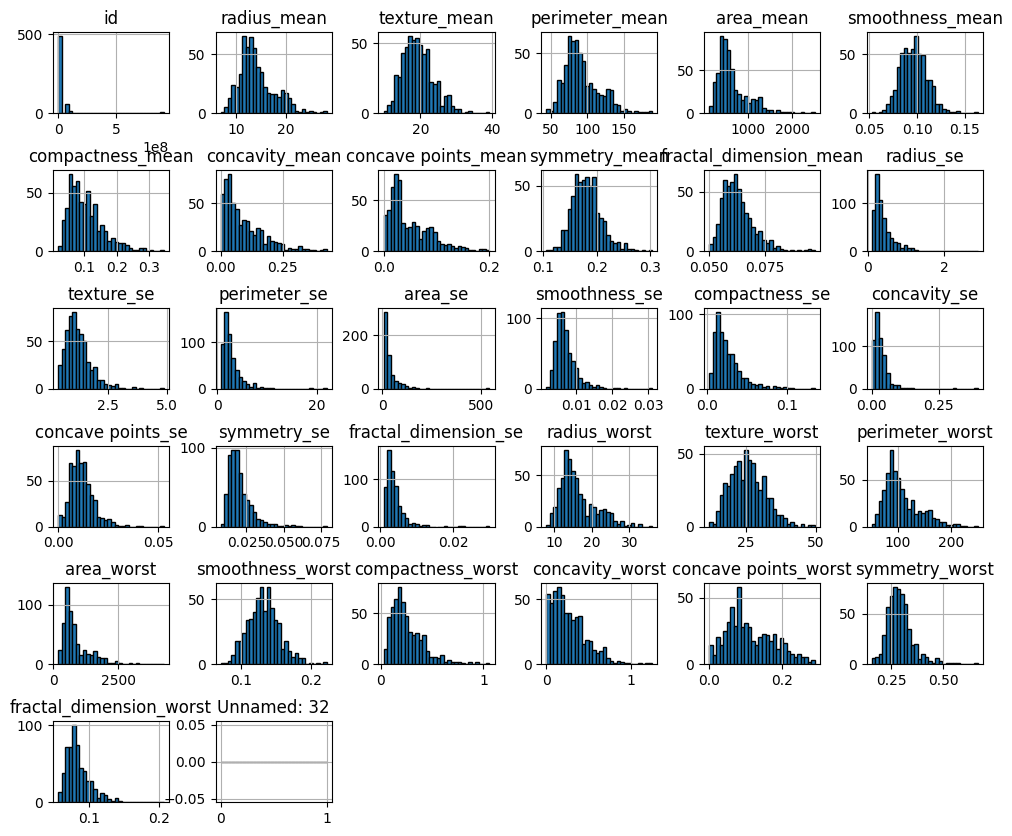

In [ ]:
df.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)

In [ ]:

print(df['diagnosis'].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


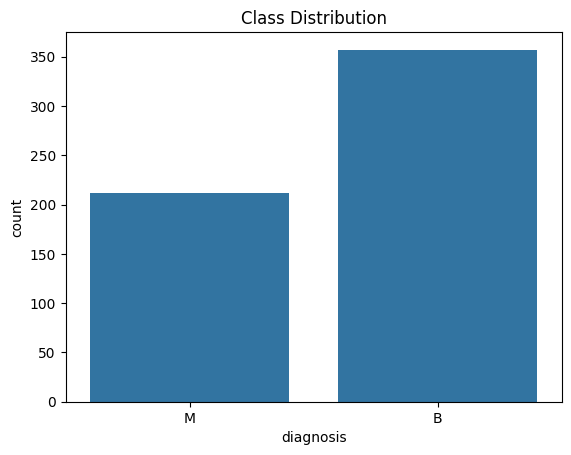

In [ ]:
sns.countplot(x='diagnosis', data=df)
plt.title("Class Distribution")
plt.show()


In [ ]:
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

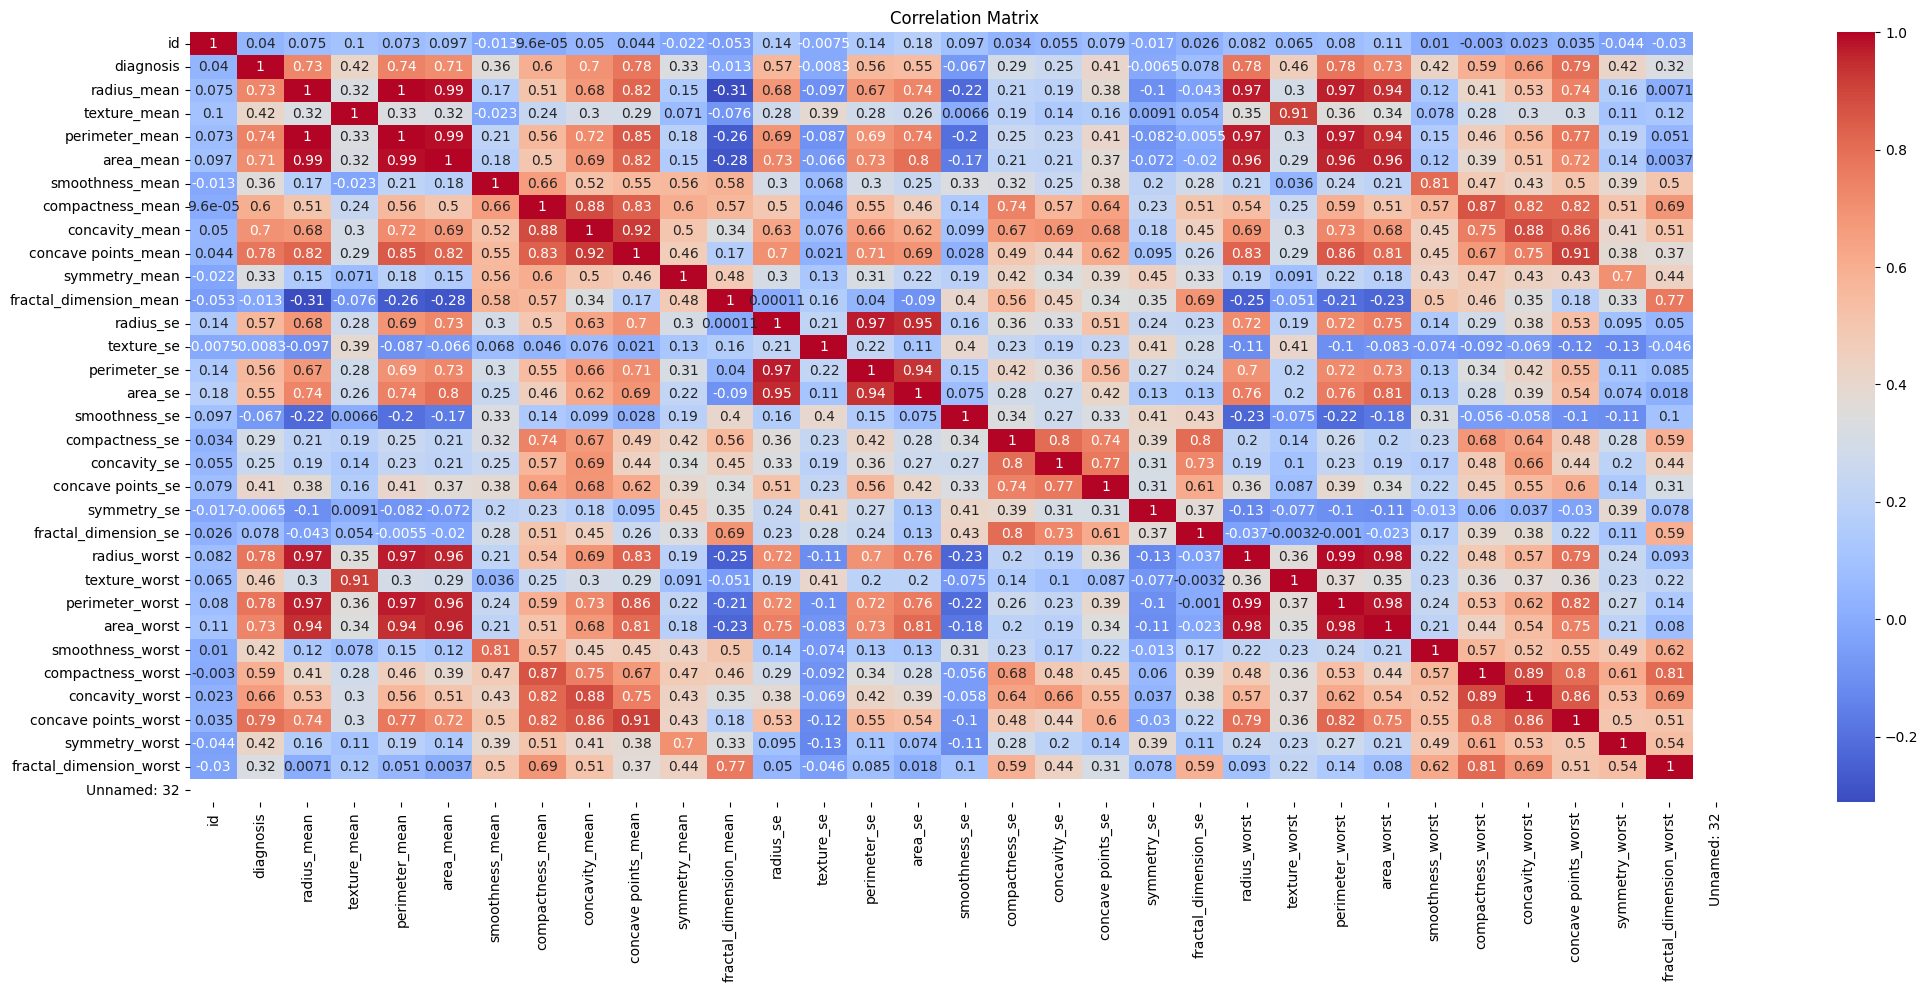

In [ ]:
plt.figure(figsize=(25,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
columns_to_drop = [
    "id", "Unnamed: 32",
    "perimeter_mean", "radius_mean", "radius_worst",
    "perimeter_worst", "radius_se", "perimeter_se",
    "concavity_mean", "area_mean",
    "concavity_worst", "concavity_se"
]

df.drop(columns=columns_to_drop, inplace=True, errors="ignore")
## We checked correlation between features and the ones with high correlation show redundancy
# thus they must be removed/eliminated to remove the curse of dimensionality


In [ ]:
X = df.drop("diagnosis", axis=1).values
y = df["diagnosis"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def manhattan_distance(a, b):
    return np.sum(np.abs(a - b))

def minkowski_distance(a, b, p):
    return (np.sum(np.abs(a - b) ** p)) ** (1 / p)


In [ ]:
class KNN:
    def __init__(self, k=3, p=2):  # p=1 → Manhattan, p=2 → Euclidean
        self.k = k
        self.p = p

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        return np.array([self._predict(x) for x in X])

    def _predict(self, x):
        distances = [
            minkowski_distance(x, x_train, self.p)
            for x_train in self.X_train
        ]

        k_indices = np.argsort(distances)[:self.k]
        k_labels = [self.y_train[i] for i in k_indices]

        return Counter(k_labels).most_common(1)[0][0]


In [ ]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


In [ ]:
for p, metric in [(1, "Manhattan"), (2, "Euclidean")]:
    print(f"\nDistance Metric: {metric}")
    for k in [3, 5, 7]:
        knn = KNN(k=k, p=p)
        knn.fit(X_train, y_train)

        train_acc = accuracy(y_train, knn.predict(X_train))
        test_acc = accuracy(y_test, knn.predict(X_test))

        print(f"k={k} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")



Distance Metric: Manhattan
k=3 | Train Acc: 0.9846 | Test Acc: 0.9211
k=5 | Train Acc: 0.9648 | Test Acc: 0.9211
k=7 | Train Acc: 0.9648 | Test Acc: 0.9211

Distance Metric: Euclidean
k=3 | Train Acc: 0.9802 | Test Acc: 0.9123
k=5 | Train Acc: 0.9626 | Test Acc: 0.9211
k=7 | Train Acc: 0.9626 | Test Acc: 0.9123


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, StratifiedKFold, LeaveOneOut
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
k_values = [1, 3, 5, 7, 9]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
random_cv_acc = []

for k in k_values:
    acc = []
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_tr, y_tr)
        acc.append(accuracy_score(y_val, model.predict(X_val)))

    random_cv_acc.append(np.mean(acc))
print(random_cv_acc)

[np.float64(0.9384615384615385), np.float64(0.9472527472527472), np.float64(0.945054945054945), np.float64(0.945054945054945), np.float64(0.9472527472527472)]


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stratified_cv_acc = []

for k in k_values:
    acc = []
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_tr, y_tr)
        acc.append(accuracy_score(y_val, model.predict(X_val)))

    stratified_cv_acc.append(np.mean(acc))
print(stratified_cv_acc)

[np.float64(0.9516483516483516), np.float64(0.9472527472527472), np.float64(0.9472527472527472), np.float64(0.9538461538461538), np.float64(0.956043956043956)]


In [ ]:
loo = LeaveOneOut()
loo_cv_acc = []

for k in k_values:
    acc = []
    for train_idx, val_idx in loo.split(X_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_tr, y_tr)
        acc.append(accuracy_score(y_val, model.predict(X_val)))

    loo_cv_acc.append(np.mean(acc))
print(loo_cv_acc)

[np.float64(0.945054945054945), np.float64(0.945054945054945), np.float64(0.9472527472527472), np.float64(0.9516483516483516), np.float64(0.9494505494505494)]


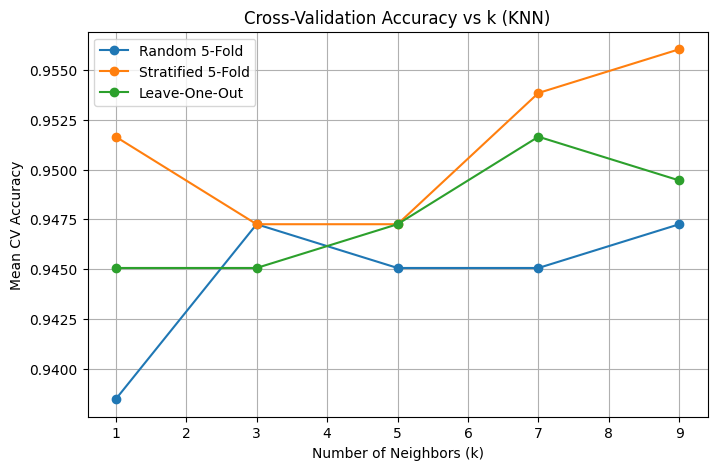

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, random_cv_acc, marker='o', label="Random 5-Fold")
plt.plot(k_values, stratified_cv_acc, marker='o', label="Stratified 5-Fold")
plt.plot(k_values, loo_cv_acc, marker='o', label="Leave-One-Out")

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean CV Accuracy")
plt.title("Cross-Validation Accuracy vs k (KNN)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
best_k = 5

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)

y_test_pred = final_knn.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy for k = {best_k}: {test_accuracy:.4f}")


Test Accuracy for k = 5: 0.9211


<h2>Why is KNN called a lazy algorithm?</h2>

<p>k-Nearest Neighbors (k-NN) is called a lazy learning algorithm because it does not learn a model during training. Instead of building a mathematical model, it simply stores the entire training dataset.</p>

<p>When a new data point is given, k-NN calculates the distance between that point and all training samples, finds the nearest neighbors, and makes a decision based on them. Because learning is delayed until prediction time, it is referred to as lazy learning.</p>

### Part B:-

In [ ]:
df = pd.read_csv('/content/Advertising Budget and Sales.csv')

print(df.head()) # first some rows
print("Features:", df.columns.tolist()) # Feature names

print("Dataset shape:", df.shape)


   Unnamed: 0  TV Ad Budget ($)  Radio Ad Budget ($)  Newspaper Ad Budget ($)  \
0           1             230.1                 37.8                     69.2   
1           2              44.5                 39.3                     45.1   
2           3              17.2                 45.9                     69.3   
3           4             151.5                 41.3                     58.5   
4           5             180.8                 10.8                     58.4   

   Sales ($)  
0       22.1  
1       10.4  
2        9.3  
3       18.5  
4       12.9  
Features: ['Unnamed: 0', 'TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)', 'Sales ($)']
Dataset shape: (200, 5)


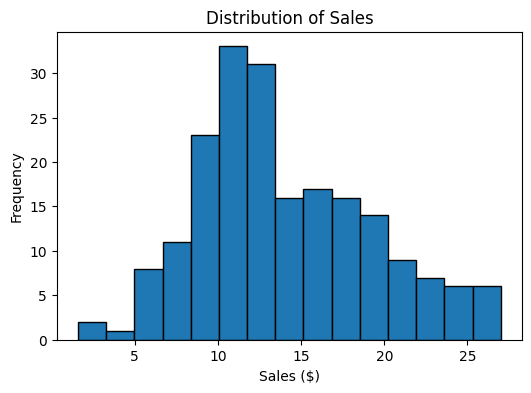

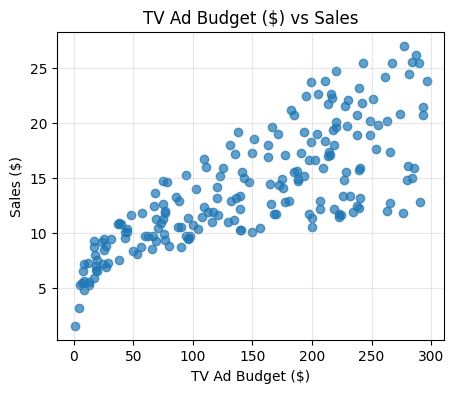

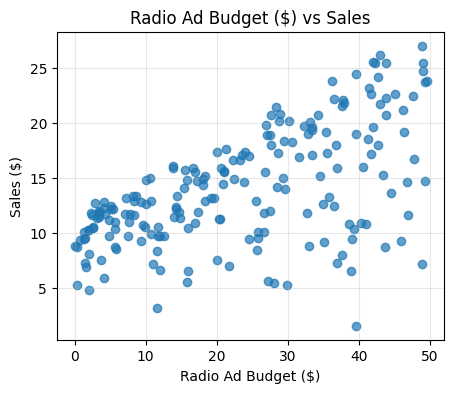

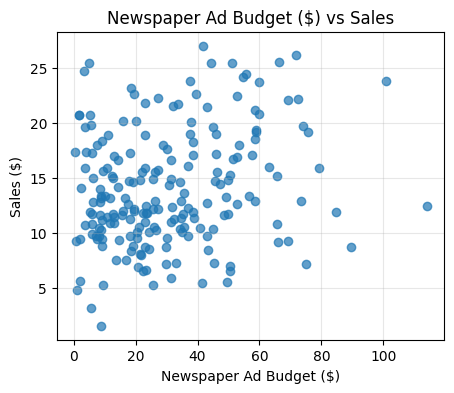

In [ ]:

# Histogram of Sales
plt.figure(figsize=(6,4))
plt.hist(df['Sales ($)'], bins=15, edgecolor='black')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Sales')
plt.show()

features = ['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']

for f in features:
    plt.figure(figsize=(5,4))
    plt.scatter(df[f], df['Sales ($)'], alpha=0.7)
    plt.xlabel(f)
    plt.ylabel('Sales ($)')
    plt.title(f'{f} vs Sales')
    plt.grid(alpha=0.3)
    plt.show()


In [ ]:
import numpy as np

def simple_linear_regression(X, y):
    X = np.array(X)
    y = np.array(y)

    X_mean = X.mean()
    y_mean = y.mean()

    b1 = np.sum((X - X_mean)*(y - y_mean)) / np.sum((X - X_mean)**2)
    b0 = y_mean - b1*X_mean

    return b0, b1

# Simple regression using TV data
b0, b1 = simple_linear_regression(df['TV Ad Budget ($)'], df['Sales ($)'])
print("Intercept:", b0)
print("Slope:", b1)


Intercept: 7.0325935491276965
Slope: 0.047536640433019736


In [ ]:
def multiple_linear_regression(X, y):
    X = np.c_[np.ones(len(X)), X]
    y = np.array(y)

    beta = np.linalg.inv(X.T @ X) @ X.T @ y
    return beta

X = df[['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']]
y = df['Sales ($)']

beta = multiple_linear_regression(X, y)
print("Regression coefficients:", beta)


Regression coefficients: [ 2.93888937e+00  4.57646455e-02  1.88530017e-01 -1.03749304e-03]


In [ ]:
degrees = [1, 2, 3, 4]
k_values = [1, 2, 3, 5]
mse_scores = []

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, X_poly, y,
        scoring='neg_mean_squared_error',
        cv=kf
    )

    mse = -scores.mean()
    mse_scores.append(mse)
    print(f"Degree {d} → Mean CV MSE: {mse:.3f}")

Degree 1 → Mean CV MSE: 2.965
Degree 2 → Mean CV MSE: 0.435
Degree 3 → Mean CV MSE: 0.335
Degree 4 → Mean CV MSE: 0.386


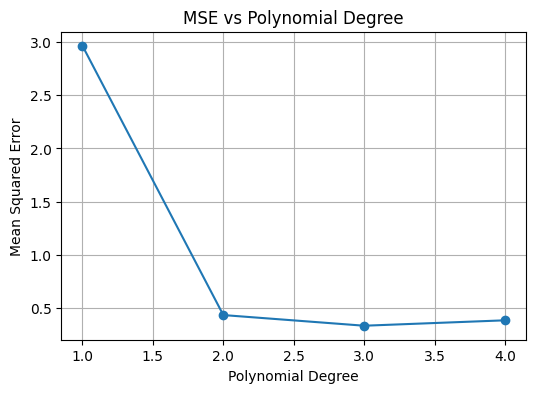

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(degrees, mse_scores, marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('MSE vs Polynomial Degree')
plt.grid()
plt.show()


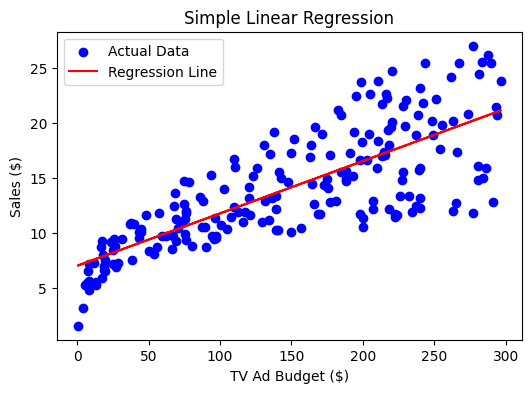

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X_tv = df['TV Ad Budget ($)'].values
y = df['Sales ($)'].values

b0, b1 = simple_linear_regression(X_tv, y)

y_pred = b0 + b1 * X_tv

plt.figure(figsize=(6,4))
plt.scatter(X_tv, y, color='blue', label='Actual Data')
plt.plot(X_tv, y_pred, color='red', label='Regression Line')
plt.xlabel('TV Ad Budget ($)')
plt.ylabel('Sales ($)')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()


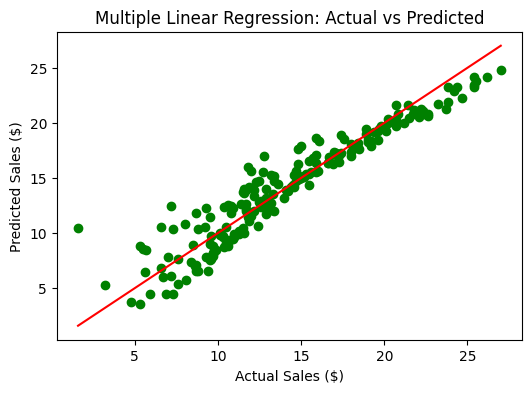

In [ ]:
from sklearn.linear_model import LinearRegression

X = df[['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']]
y = df['Sales ($)']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

plt.figure(figsize=(6,4))
plt.scatter(y, y_pred, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')
plt.xlabel('Actual Sales ($)')
plt.ylabel('Predicted Sales ($)')
plt.title('Multiple Linear Regression: Actual vs Predicted')
plt.show()


<h2>Results Discussion</h2>

<p>Simple linear regression used only one feature and showed limited performance. The error values were higher, and the R-squared value was low, indicating that a single feature is not sufficient to explain sales behavior.</p>

<p>Multiple linear regression performed better because it used all available advertising features. This reduced the Mean Absolute Error and increased the R-squared value, showing improved prediction accuracy.</p>

<p>Overall, multiple linear regression with degree 1 polynomial features gave the best balance between accuracy and generalization. This shows that sales depend on multiple advertising channels, but the relationship is mostly linear.</p>